In [ ]:
## Imports
import os
import sys
import random

import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

## Seeding 
seed = 2019
random.seed = seed
np.random.seed = seed
tf.seed = seed

# from google.colab import files as FILE
# import requests

The first step was to load the dataset to google colab. For that I first downloaded the given dataset and uploaded it on my drive and then loaded it here.

https://medium.com/geekculture/how-to-load-a-dataset-from-the-google-drive-to-google-colab-67d0478bc634

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Then I saw the video posted on MS Teams in which UNet Architecture was explained and a piece of code was also available. Using that as base code I tried to implement a separate function of displaying images

https://github.com/nikhilroxtomar/UNet-Segmentation-in-Keras-TensorFlow/blob/master/unet-segmentation.ipynb

In [62]:
class DataGen(keras.utils.Sequence):
  def __init__(self, ids, path, batch_size = 4, image_size = 1000):
    self.ids = ids
    self.path = path
    self.batch_size = batch_size
    self.image_size = image_size
    self.on_epoch_end()

  def __load__(self, id_name):
    image_path = os.path.join(self.path, "Tissue-Images", id_name)
    mask_path = os.path.join(self.path, "Binary-Mask", id_name)
    # print(image_path)

    #Reading image and mask
    image = cv2.imread(image_path, 1)
    # print(image)

    image = cv2.resize(image, (self.image_size, self.image_size))
    mask = cv2.imread(mask_path, 1)
    mask = cv2.resize(mask, (self.image_size, self.image_size))
    # mask = np.reshape(mask[:, :, 0], (image_size, image_size, 1))

    image = image/255.0
    mask = mask/255.0

    return image, mask

  def display(self, id_name):
    image, mask = self._load_(id_name)

    image = image*255.0
    mask = mask*255.0

    result = np.concatenate((image, mask), axis = 1)
    return result

  def __getitem__(self, index):
    if(index+1)*self.batch_size > len(self.ids):
      self.batch_size = len(self.ids) - index*self.batch_size
        
    files_batch = self.ids[index*self.batch_size : (index+1)*self.batch_size]
        
    image = []
    mask  = []
    # yTrue[i] = (np.reshape(yTrue[0], (image_size, image_size, 1)))
    for id_name in files_batch:
      _img, _mask = self.__load__(id_name)
      image.append(_img)
      mask.append(_mask)
      # mask.append(np.reshape(_mask[:, :, 0], (image_size, image_size, 1)))
            
    image = np.array(image)
    mask  = np.array(mask)
    # print(mask.shape)
        
    return image, mask

  def on_epoch_end(self):
    pass

  def __len__(self):
        return int(np.ceil(len(self.ids)/float(self.batch_size)))

There was some problem regarding the dimensions of the image as the number of channels in the mask image and predicted image was different. 

Some parameters

In [ ]:
batch_size = 4
epochs = 10
image_size = 512

train_path_ids = "/content/drive/MyDrive/MoNuSeg-Training-Data/Tissue-Images"   #For getting the name of images(ids)
test_path_ids = "/content/drive/MyDrive/MoNuSeg-Test-Data/Tissue-Images"        #For getting the name of images(ids)
train_path = "/content/drive/MyDrive/MoNuSeg-Training-Data"
test_path = "/content/drive/MyDrive/MoNuSeg-Test-Data"

train_ids = next(os.walk(train_path_ids))[2]
test_ids = next(os.walk(test_path_ids))[2]

val_data_size = 6

valid_ids = train_ids[:val_data_size]
train_ids = train_ids[val_data_size:]

# print(train_ids)

## Question 1: Displaying some images

In [ ]:
train_ids_display = train_ids[:3]
print(train_ids_display)

['TCGA-B0-5698-01Z-00-DX1.png', 'TCGA-AR-A1AK-01Z-00-DX1.png', 'TCGA-HE-7128-01Z-00-DX1.png']


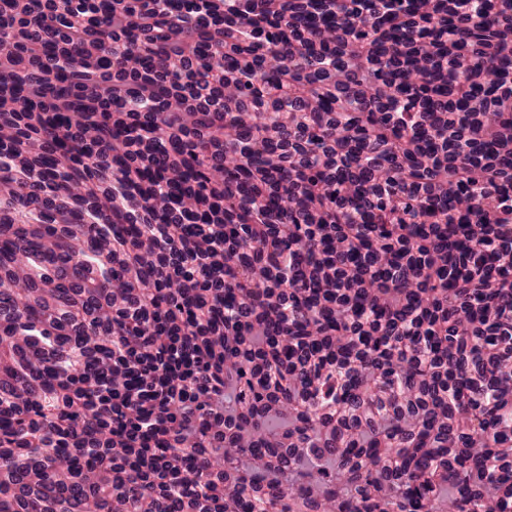

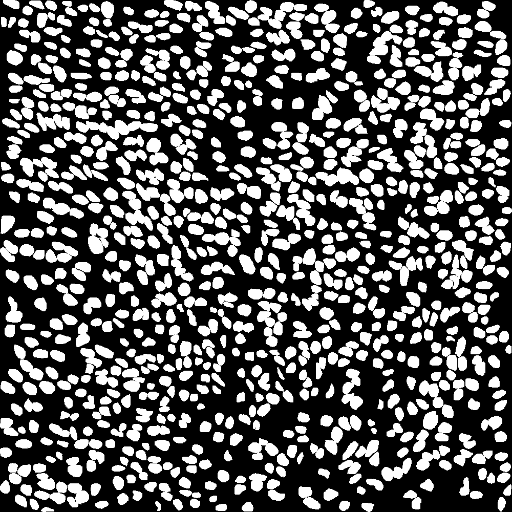

(512, 512, 3) (512, 512, 3)
Training dataset image 1


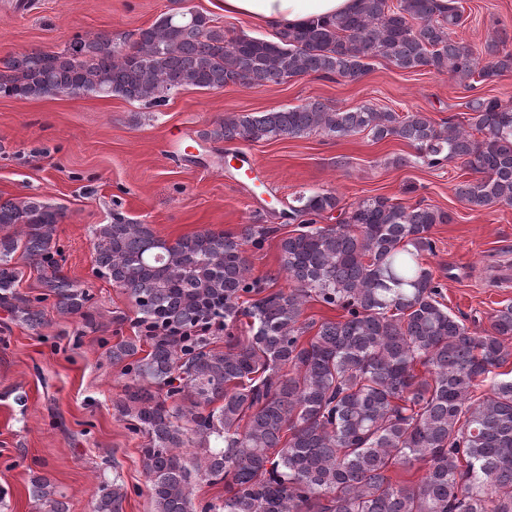

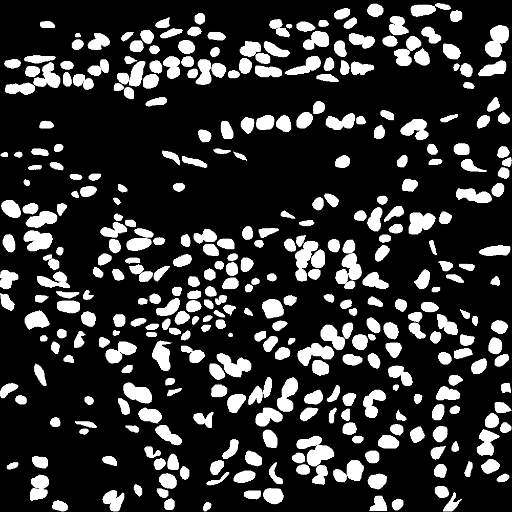

(512, 512, 3) (512, 512, 3)
Training dataset image 2


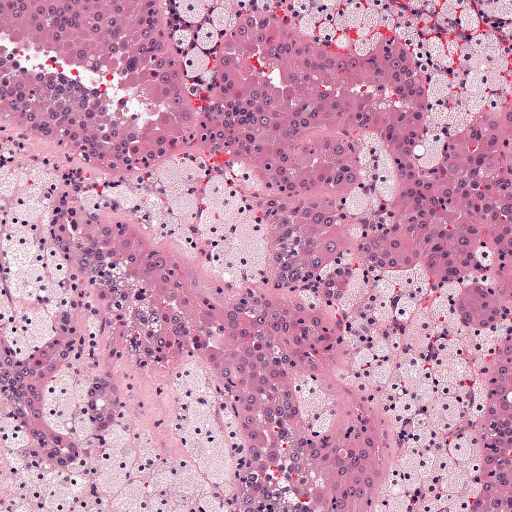

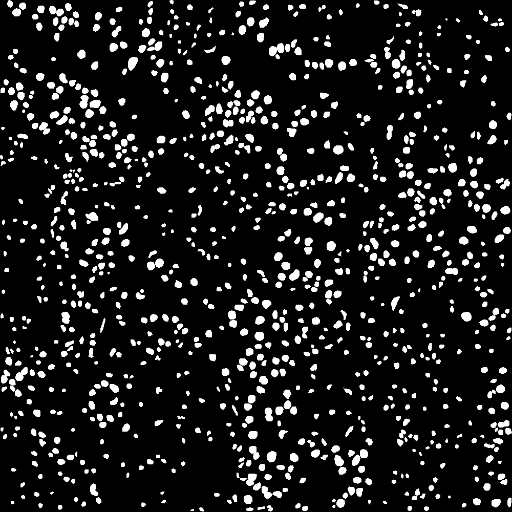

(512, 512, 3) (512, 512, 3)
Training dataset image 3


In [ ]:
gen_display_train = DataGen(train_ids_display, train_path, batch_size, image_size)
for i in range (0, 3):
  image, mask = gen_display_train.__load__(train_ids_display[i])
  cv2_imshow(image*255)
  cv2_imshow(mask*255)
  print(image.shape, mask.shape)
  # print(result[1].shape)
  print("Training dataset image", i+1)

In [ ]:
test_ids_display = test_ids[:3]
print(test_ids_display)

['TCGA-GL-6846-01A-01-BS1.png', 'TCGA-A6-6782-01A-01-BS1.png', 'TCGA-69-7764-01A-01-TS1.png']


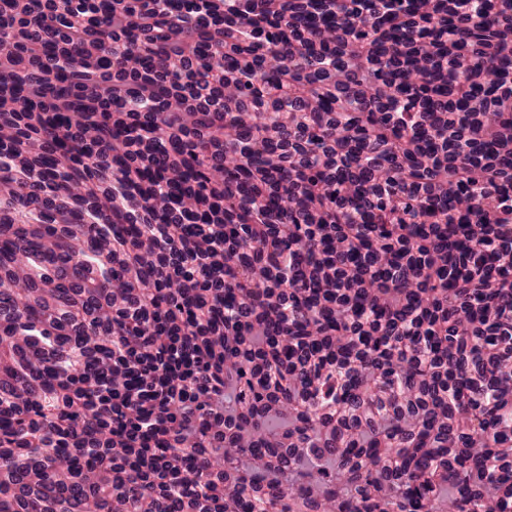

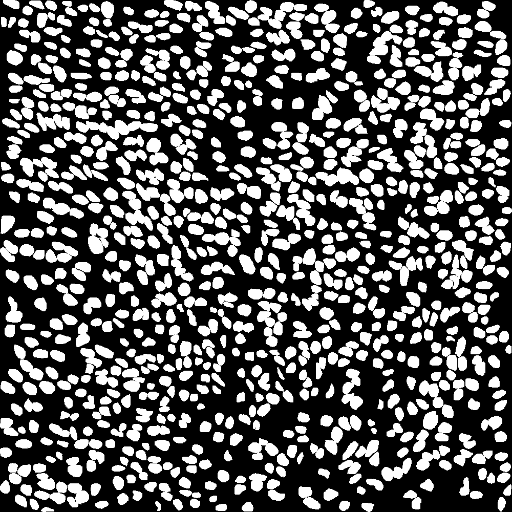

Testing dataset image 1


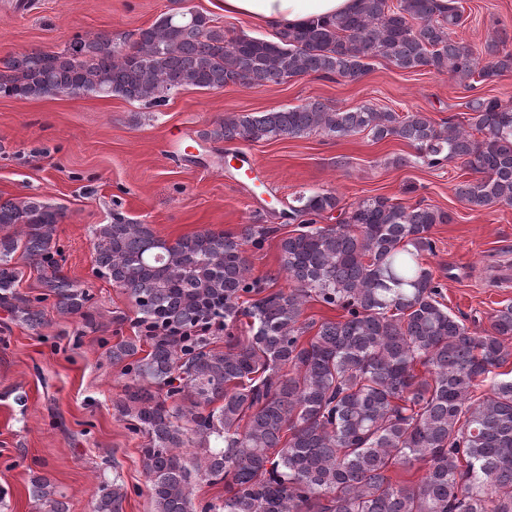

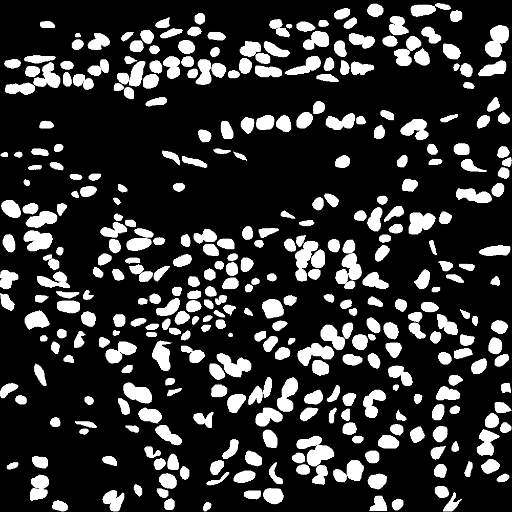

Testing dataset image 2


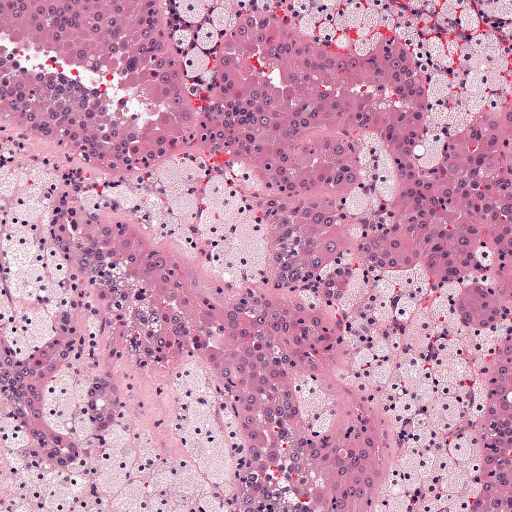

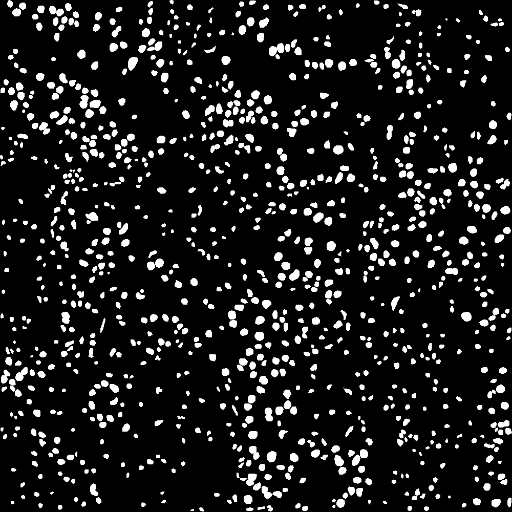

Testing dataset image 3


In [ ]:
gen_display_test = DataGen(test_ids_display, test_path, batch_size, image_size)
# print(gen_display_test)
for i in range (0, 3):
  image, mask = gen_display_train.__load__(train_ids_display[i])
  cv2_imshow(image*255)
  cv2_imshow(mask*255)
  print("Testing dataset image", i+1)

## Basic Semantic Segmentation

Convolutional Blocks

In [ ]:
def down_block(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    c = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(x)
    c = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(c)
    p = keras.layers.MaxPool2D((2, 2), (2, 2))(c)
    return c, p

def up_block(x, skip, filters, kernel_size=(3, 3), padding="same", strides=1):
    us = keras.layers.UpSampling2D((2, 2))(x)
    concat = keras.layers.Concatenate()([us, skip])
    c = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(concat)
    c = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(c)
    return c

def bottleneck(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    c = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(x)
    c = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(c)
    return c

In [ ]:
def UNet():

  # f = [16, 32, 64, 128, 256]
  f = [64, 128, 256, 512, 1024]
  inputs = keras.layers.Input((image_size, image_size, 3))
  print(inputs)
    
  p0 = inputs
  c1, p1 = down_block(p0, f[0]) #128 -> 64
  c2, p2 = down_block(p1, f[1]) #64 -> 32
  c3, p3 = down_block(p2, f[2]) #32 -> 16
  c4, p4 = down_block(p3, f[3]) #16->8
    
  bn = bottleneck(p4, f[4])
    
  u1 = up_block(bn, c4, f[3]) #8 -> 16
  u2 = up_block(u1, c3, f[2]) #16 -> 32
  u3 = up_block(u2, c2, f[1]) #32 -> 64
  u4 = up_block(u3, c1, f[0]) #64 -> 128
    
  outputs = keras.layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(u4)
  model = keras.models.Model(inputs, outputs)
  return model

## Dice Loss

I got the idea of dice loss from the following and according to that wrote this dice function https://arxiv.org/pdf/1606.04797v1.pdf

In [ ]:
def dice_loss(yTrue, yPred):
  dice_coeff = 2*tf.math.reduce_sum(yTrue*yPred, axis = [1, 2, 3])/(tf.math.reduce_sum(yTrue*yTrue, axis = [1, 2, 3]) + tf.math.reduce_sum(yPred*yPred, axis = [1, 2, 3]))
  return 1 - dice_coeff

I then tried to use both binary crossentropy and dice loss for training the model

In [ ]:
model = UNet()
model.compile(optimizer="adam", loss=dice_loss, metrics=["accuracy"])
# model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["acc"])
model.summary()
# print(model)

KerasTensor(type_spec=TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='input_2'), name='input_2', description="created by layer 'input_2'")
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_19 (Conv2D)             (None, 512, 512, 64  1792        ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_20 (Conv2D)             (None,

Training

In [ ]:
# print(train_ids)
train_gen = DataGen(train_ids, train_path, image_size=image_size, batch_size=batch_size)
valid_gen = DataGen(valid_ids, train_path, image_size=image_size, batch_size=batch_size)
test_gen = DataGen(test_ids, test_path, image_size=image_size, batch_size=batch_size)
# print(train_gen)

train_steps = len(train_ids)//batch_size
valid_steps = len(valid_ids)//batch_size

In [ ]:
model.fit_generator(train_gen, validation_data=valid_gen, steps_per_epoch=train_steps, validation_steps=valid_steps, epochs=epochs)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  """Entry point for launching an IPython kernel.


Epoch 1/10
6/6 [==============================] - 8s 1s/step - loss: 81.9969 - acc: 0.6035 - val_loss: 0.6426 - val_acc: 0.7628
Epoch 2/10
6/6 [==============================] - 6s 993ms/step - loss: 0.6252 - acc: 0.7014 - val_loss: 0.5103 - val_acc: 0.7628
Epoch 3/10
6/6 [==============================] - 6s 998ms/step - loss: 0.5437 - acc: 0.7014 - val_loss: 0.4907 - val_acc: 0.7628
Epoch 4/10
6/6 [==============================] - 6s 1s/step - loss: 0.5208 - acc: 0.7014 - val_loss: 0.4716 - val_acc: 0.7628
Epoch 5/10
6/6 [==============================] - 6s 1s/step - loss: 0.5037 - acc: 0.7014 - val_loss: 0.4550 - val_acc: 0.7628
Epoch 6/10
6/6 [==============================] - 6s 1s/step - loss: 0.4615 - acc: 0.7392 - val_loss: 0.4803 - val_acc: 0.7628
Epoch 7/10
6/6 [==============================] - 6s 1s/step - loss: 0.4412 - acc: 0.7610 - val_loss: 0.3916 - val_acc: 0.8117
Epoch 8/10
6/6 [==============================] - 6s 999ms/step - loss: 0.4237 - acc: 0.7758 - val_loss:

Testing

In [ ]:
# Here I tried to clear my concept of image channels and found the dimensions of all the images and tried interconverting them

x, y = valid_gen.__getitem__(1)
print(y.shape)
y1 = y[0]
print(y1.shape)
y1 = y1[:, :, 0]
print(y1.shape)
y1 = np.reshape(y1, (image_size, image_size, 1))
print(y1.shape)

(2, 128, 128, 3)
(128, 128, 3)
(128, 128)
(128, 128, 1)


This is the testing done on the validation dataset. I converted both the original and predicted image to (img_size X img_size) from a 3 dimensional 3 channel and single channel image respectively so that I can print them together

In [ ]:
# Weights
model.save_weights("UNetW.h5")

# Dataset for prediction
x, y = valid_gen.__getitem__(1)
result = model.predict(x)
watershed_input = result
print(x.shape, y.shape, result.shape)
# # cv2_imshow(result[0]*255)
# # print(result)
# cv2_imshow(result[0]*255)
# cv2_imshow(y[0]*255)
result = result > 0.4
# # print(result)
# cv2_imshow(y[0]*255)
# cv2_imshow(result[0]*255)


yTrue = [0]*y.shape[0]
res = [0]*y.shape[0]
for i in range (y.shape[0]):
  yTrue[i] = y[i][:, :, 0]*255
  res[i] = result[i][:, :, 0]*255
  # yTrue[i] = (np.reshape(yTrue[0], (image_size, image_size, 1)))
  print(yTrue[0].shape)
# print(result.shape)
# print(yTrue.shape)
# watershed_input = res[0]
print(yTrue[0].shape, result[0].shape)



# cv2_imshow(y[0]*255)
# cv2_imshow(result[0]*255)

1/1 [==============================] - 0s 25ms/step
(2, 512, 512, 3) (2, 512, 512, 3) (2, 512, 512, 1)
(512, 512)
(512, 512)
(512, 512) (512, 512, 1)


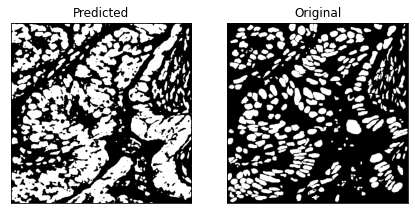

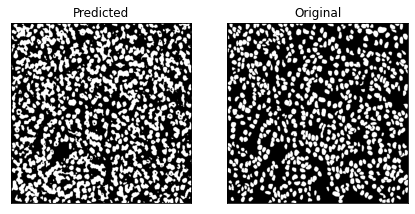

In [ ]:
for i in range (y.shape[0]):
  plt.figure(figsize=(11,6))
  plt.subplot(131), plt.imshow(res[i],cmap='gray'),plt.title('Predicted')
  plt.xticks([]), plt.yticks([])
  plt.subplot(132), plt.imshow(yTrue[i],cmap='gray'),plt.title('Original')
  plt.xticks([]), plt.yticks([])
  plt.show()

Implementation on testing data


In [ ]:
# Weights
model.save_weights("UNetW.h5")

# Dataset for prediction
x, y = test_gen.__getitem__(1)
result = model.predict(x)
watershed_input = result
print(x.shape, y.shape, result.shape)
# # cv2_imshow(result[0]*255)
# # print(result)
# cv2_imshow(result[0]*255)
# cv2_imshow(y[0]*255)
result = result > 0.5
# # print(result)
# cv2_imshow(y[0]*255)
# cv2_imshow(result[0]*255)


yTrue = [0]*y.shape[0]
res = [0]*y.shape[0]
for i in range (y.shape[0]):
  yTrue[i] = y[i][:, :, 0]*255
  res[i] = result[i][:, :, 0]*255
  # yTrue[i] = (np.reshape(yTrue[0], (image_size, image_size, 1)))
  print(yTrue[0].shape)
# print(result.shape)
# print(yTrue.shape)
# watershed_input = res[0]
print(yTrue[0].shape, result[0].shape)



# cv2_imshow(y[0]*255)
# cv2_imshow(result[0]*255)

1/1 [==============================] - 0s 32ms/step
(4, 512, 512, 3) (4, 512, 512, 3) (4, 512, 512, 1)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512) (512, 512, 1)


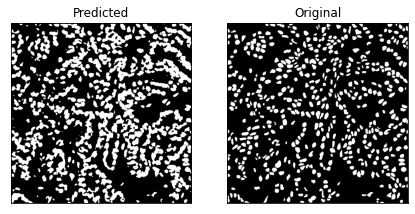

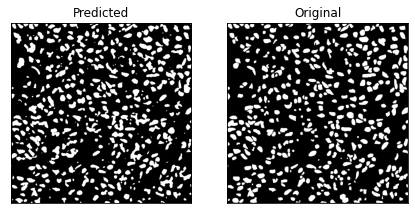

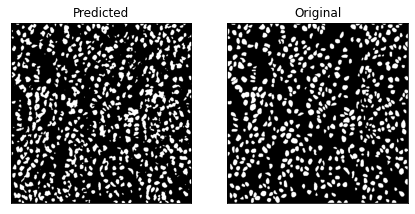

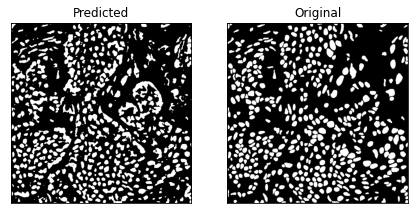

In [ ]:
for i in range (y.shape[0]):
  plt.figure(figsize=(11,6))
  plt.subplot(131), plt.imshow(res[i],cmap='gray'),plt.title('Predicted')
  plt.xticks([]), plt.yticks([])
  plt.subplot(132), plt.imshow(yTrue[i],cmap='gray'),plt.title('Original')
  plt.xticks([]), plt.yticks([])
  plt.show()

# Modification - Ques5

# Modifying no. of blocks in UNet architecture

Originally 4 downsampling and upsampling blocks were used. Here I reduced the no. of blocks to 3 and then 2

In [ ]:
def UNet_3blocks():

  # f = [16, 32, 64, 128, 256]
  f = [64, 128, 256, 512, 1024]
  inputs = keras.layers.Input((image_size, image_size, 3))
  print(inputs)
    
  p0 = inputs
  c1, p1 = down_block(p0, f[0]) #128 -> 64
  c2, p2 = down_block(p1, f[1]) #64 -> 32
  c3, p3 = down_block(p2, f[2]) #32 -> 16
    
  bn = bottleneck(p3, f[3])

  u1 = up_block(bn, c3, f[2]) #16 -> 32
  u2 = up_block(u1, c2, f[1]) #32 -> 64
  u3 = up_block(u2, c1, f[0]) #64 -> 128
    
  outputs = keras.layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(u3)
  model = keras.models.Model(inputs, outputs)
  return model

In [ ]:
model_3blocks = UNet_3blocks()
model_3blocks.compile(optimizer="adam", loss=dice_loss, metrics=["accuracy"])
model_3blocks.summary()

KerasTensor(type_spec=TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='input_6'), name='input_6', description="created by layer 'input_6'")
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_83 (Conv2D)             (None, 512, 512, 64  1792        ['input_6[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_84 (Conv2D)             (None,

In [ ]:
model_3blocks.fit_generator(train_gen, validation_data=valid_gen, steps_per_epoch=train_steps, validation_steps=valid_steps, epochs=epochs)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  """Entry point for launching an IPython kernel.


Epoch 1/10
6/6 [==============================] - 7s 894ms/step - loss: 0.6445 - acc: 0.6322 - val_loss: 0.5381 - val_acc: 0.7628
Epoch 2/10
6/6 [==============================] - 5s 824ms/step - loss: 0.5411 - acc: 0.7014 - val_loss: 0.4807 - val_acc: 0.7628
Epoch 3/10
6/6 [==============================] - 5s 819ms/step - loss: 0.5025 - acc: 0.7014 - val_loss: 0.4600 - val_acc: 0.7628
Epoch 4/10
6/6 [==============================] - 5s 818ms/step - loss: 0.5092 - acc: 0.6843 - val_loss: 0.5172 - val_acc: 0.7628
Epoch 5/10
6/6 [==============================] - 5s 819ms/step - loss: 0.4777 - acc: 0.7118 - val_loss: 0.4271 - val_acc: 0.7638
Epoch 6/10
6/6 [==============================] - 5s 828ms/step - loss: 0.4452 - acc: 0.7561 - val_loss: 0.5090 - val_acc: 0.7633
Epoch 7/10
6/6 [==============================] - 5s 815ms/step - loss: 0.4533 - acc: 0.7787 - val_loss: 0.4116 - val_acc: 0.7700
Epoch 8/10
6/6 [==============================] - 5s 815ms/step - loss: 0.4398 - acc: 0.76

Testing

In [ ]:
# Weights
model_3blocks.save_weights("UNetW.h5")

# Dataset for prediction
x_3blocks, y_3blocks = valid_gen.__getitem__(1)
result_3blocks = model_3blocks.predict(x_3blocks)
print(x_3blocks.shape, y_3blocks.shape, result_3blocks.shape)
result_3blocks = result_3blocks > 0.5

yTrue_3blocks = [0]*y_3blocks.shape[0]
res_3blocks = [0]*y_3blocks.shape[0]

for i in range (y_3blocks.shape[0]):
  res_3blocks[i] = result_3blocks[i][:, :, 0]*255
  yTrue_3blocks[i] = y_3blocks[i][:, :, 0]*255
  print(yTrue_3blocks[0].shape, res_3blocks[0].shape)

1/1 [==============================] - 0s 188ms/step
(2, 512, 512, 3) (2, 512, 512, 3) (2, 512, 512, 1)
(512, 512) (512, 512)
(512, 512) (512, 512)


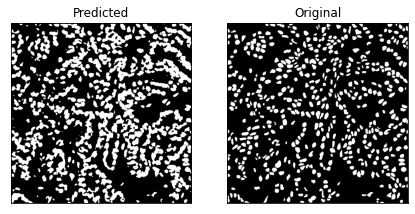

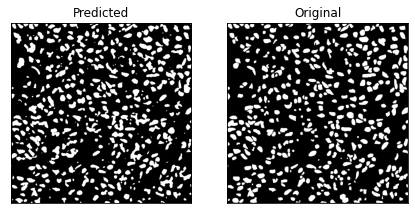

In [ ]:
for i in range (y_3blocks.shape[0]):
  plt.figure(figsize=(11,6))
  plt.subplot(131), plt.imshow(res[i],cmap='gray'),plt.title('Predicted')
  plt.xticks([]), plt.yticks([])
  plt.subplot(132), plt.imshow(yTrue[i],cmap='gray'),plt.title('Original')
  plt.xticks([]), plt.yticks([])
  plt.show()

Testing data

In [ ]:
# Weights
model_3blocks.save_weights("UNetW.h5")

# Dataset for prediction
x_3blocks, y_3blocks = test_gen.__getitem__(1)
result_3blocks = model_3blocks.predict(x_3blocks)
print(x_3blocks.shape, y_3blocks.shape, result_3blocks.shape)
result_3blocks = result_3blocks > 0.5

yTrue_3blocks = [0]*y_3blocks.shape[0]
res_3blocks = [0]*y_3blocks.shape[0]

for i in range (y_3blocks.shape[0]):
  res_3blocks[i] = result_3blocks[i][:, :, 0]*255
  yTrue_3blocks[i] = y_3blocks[i][:, :, 0]*255
  print(yTrue_3blocks[0].shape, res_3blocks[0].shape)

1/1 [==============================] - 0s 69ms/step
(4, 512, 512, 3) (4, 512, 512, 3) (4, 512, 512, 1)
(512, 512) (512, 512)
(512, 512) (512, 512)
(512, 512) (512, 512)
(512, 512) (512, 512)


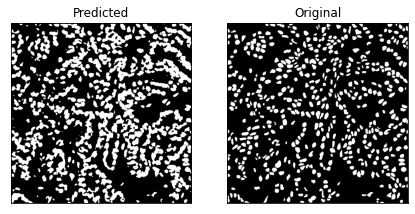

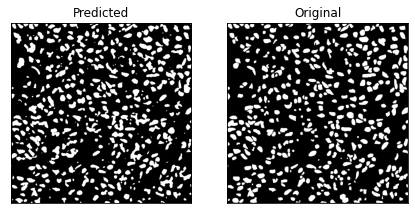

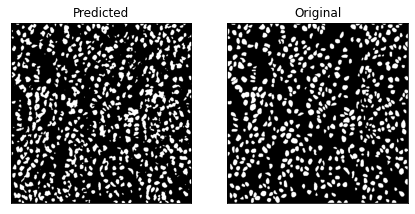

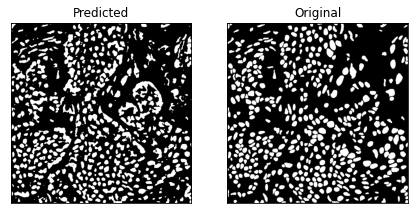

In [ ]:
for i in range (y_3blocks.shape[0]):
  plt.figure(figsize=(11,6))
  plt.subplot(131), plt.imshow(res[i],cmap='gray'),plt.title('Predicted')
  plt.xticks([]), plt.yticks([])
  plt.subplot(132), plt.imshow(yTrue[i],cmap='gray'),plt.title('Original')
  plt.xticks([]), plt.yticks([])
  plt.show()

In [ ]:
def UNet_2blocks():

  # f = [16, 32, 64, 128, 256]
  f = [64, 128, 256, 512, 1024]
  inputs = keras.layers.Input((image_size, image_size, 3))
  print(inputs)
    
  p0 = inputs
  c1, p1 = down_block(p0, f[0]) #128 -> 64
  c2, p2 = down_block(p1, f[1]) #64 -> 32
    
  bn = bottleneck(p2, f[2])

  u1 = up_block(bn, c2, f[1]) #32 -> 64
  u2 = up_block(u1, c1, f[0]) #64 -> 128
    
  outputs = keras.layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(u2)
  model = keras.models.Model(inputs, outputs)
  return model

In [ ]:
model_2blocks = UNet_2blocks()
model_2blocks.compile(optimizer="adam", loss=dice_loss, metrics=["accuracy"])
model_2blocks.summary()

KerasTensor(type_spec=TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='input_8'), name='input_8', description="created by layer 'input_8'")
Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_109 (Conv2D)            (None, 512, 512, 64  1792        ['input_8[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_110 (Conv2D)            (None,

In [ ]:
model_2blocks.fit_generator(train_gen, validation_data=valid_gen, steps_per_epoch=train_steps, validation_steps=valid_steps, epochs=epochs)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  """Entry point for launching an IPython kernel.


Epoch 1/10
6/6 [==============================] - 5s 704ms/step - loss: 0.7357 - accuracy: 0.6778 - val_loss: 0.5839 - val_accuracy: 0.7628
Epoch 2/10
6/6 [==============================] - 4s 637ms/step - loss: 0.5875 - accuracy: 0.7014 - val_loss: 0.4894 - val_accuracy: 0.7628
Epoch 3/10
6/6 [==============================] - 4s 655ms/step - loss: 0.5240 - accuracy: 0.7014 - val_loss: 0.4624 - val_accuracy: 0.7628
Epoch 4/10
6/6 [==============================] - 4s 637ms/step - loss: 0.4825 - accuracy: 0.7014 - val_loss: 0.4533 - val_accuracy: 0.7628
Epoch 5/10
6/6 [==============================] - 4s 639ms/step - loss: 0.4622 - accuracy: 0.7402 - val_loss: 0.4291 - val_accuracy: 0.7639
Epoch 6/10
6/6 [==============================] - 4s 643ms/step - loss: 0.4408 - accuracy: 0.7685 - val_loss: 0.3681 - val_accuracy: 0.7870
Epoch 7/10
6/6 [==============================] - 5s 748ms/step - loss: 0.4354 - accuracy: 0.7732 - val_loss: 0.3499 - val_accuracy: 0.8036
Epoch 8/10
6/6 [====

Testing

In [ ]:
# Weights
model_2blocks.save_weights("UNetW.h5")

# Dataset for prediction
x_2blocks, y_2blocks = valid_gen.__getitem__(1)
result_2blocks = model_2blocks.predict(x_2blocks)
print(x_2blocks.shape, y_2blocks.shape, result_2blocks.shape)
result_2blocks = result_2blocks > 0.5

yTrue_2blocks = [0]*y_2blocks.shape[0]
res_2blocks = [0]*y_2blocks.shape[0]

for i in range (y_2blocks.shape[0]):
  res_2blocks[i] = result_2blocks[i][:, :, 0]*255
  yTrue_2blocks[i] = y_2blocks[i][:, :, 0]*255
  print(yTrue_2blocks[0].shape, res_2blocks[0].shape)

1/1 [==============================] - 0s 208ms/step
(2, 512, 512, 3) (2, 512, 512, 3) (2, 512, 512, 1)
(512, 512) (512, 512)
(512, 512) (512, 512)


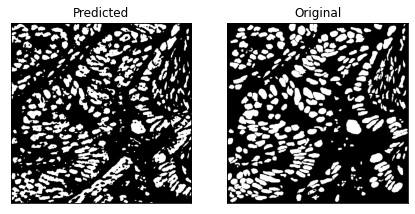

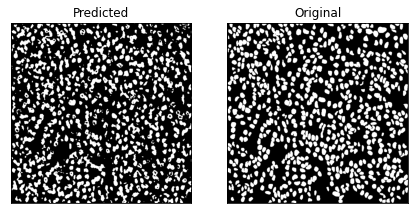

In [ ]:
for i in range (y_2blocks.shape[0]):
  plt.figure(figsize=(11,6))
  plt.subplot(131), plt.imshow(res_2blocks[i],cmap='gray'),plt.title('Predicted')
  plt.xticks([]), plt.yticks([])
  plt.subplot(132), plt.imshow(yTrue_2blocks[i],cmap='gray'),plt.title('Original')
  plt.xticks([]), plt.yticks([])
  plt.show()

Testing data

In [ ]:
# Weights
model_2blocks.save_weights("UNetW.h5")

# Dataset for prediction
x_2blocks, y_2blocks = test_gen.__getitem__(1)
result_2blocks = model_2blocks.predict(x_2blocks)
print(x_2blocks.shape, y_2blocks.shape, result_2blocks.shape)
result_2blocks = result_2blocks > 0.5

yTrue_2blocks = [0]*y_2blocks.shape[0]
res_2blocks = [0]*y_2blocks.shape[0]

for i in range (y_2blocks.shape[0]):
  res_2blocks[i] = result_2blocks[i][:, :, 0]*255
  yTrue_2blocks[i] = y_2blocks[i][:, :, 0]*255
  print(yTrue_2blocks[0].shape, res_2blocks[0].shape)

1/1 [==============================] - 0s 23ms/step
(4, 512, 512, 3) (4, 512, 512, 3) (4, 512, 512, 1)
(512, 512) (512, 512)
(512, 512) (512, 512)
(512, 512) (512, 512)
(512, 512) (512, 512)


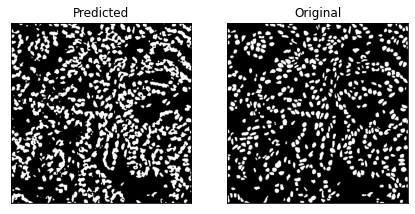

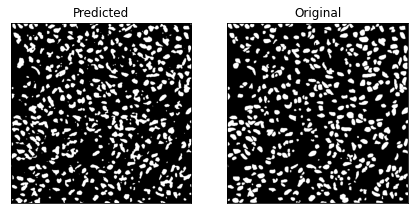

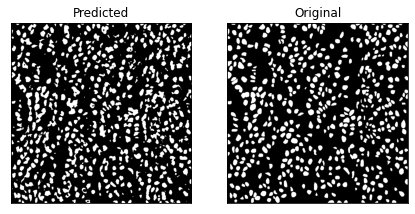

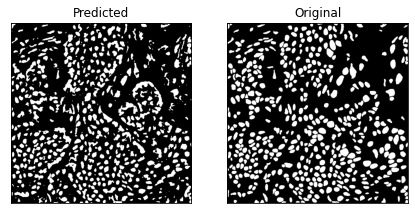

In [ ]:
for i in range (y_2blocks.shape[0]):
  plt.figure(figsize=(11,6))
  plt.subplot(131), plt.imshow(res_2blocks[i],cmap='gray'),plt.title('Predicted')
  plt.xticks([]), plt.yticks([])
  plt.subplot(132), plt.imshow(yTrue_2blocks[i],cmap='gray'),plt.title('Original')
  plt.xticks([]), plt.yticks([])
  plt.show()

# Modifying no. of filters per layer

I decreased the number of convolution at each block and modified the original UNet function

In [ ]:
def down_block_2(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    c = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(x)
    p = keras.layers.MaxPool2D((2, 2), (2, 2))(c)
    return c, p

def up_block_2(x, skip, filters, kernel_size=(3, 3), padding="same", strides=1):
    us = keras.layers.UpSampling2D((2, 2))(x)
    concat = keras.layers.Concatenate()([us, skip])
    c = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(concat)
    return c

def bottleneck_2(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    c = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides, activation="relu")(x)
    return c

In [ ]:
def UNet_2layer():

  f = [64, 128, 256, 512, 1024]
  inputs = keras.layers.Input((image_size, image_size, 3))
  print(inputs)
    
  p0 = inputs
  c1, p1 = down_block_2(p0, f[0]) 
  c2, p2 = down_block_2(p1, f[1]) 
  c3, p3 = down_block_2(p2, f[2]) 
  c4, p4 = down_block_2(p3, f[3]) 
    
  bn = bottleneck_2(p4, f[4])
    
  u1 = up_block_2(bn, c4, f[3]) 
  u2 = up_block_2(u1, c3, f[2]) 
  u3 = up_block_2(u2, c2, f[1]) 
  u4 = up_block_2(u3, c1, f[0]) 
    
  outputs = keras.layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(u4)
  model = keras.models.Model(inputs, outputs)
  return model

In [ ]:
model_2layer = UNet_2layer()
model_2layer.compile(optimizer="adam", loss=dice_loss, metrics=["accuracy"])
model_2layer.summary()
# print(model)

KerasTensor(type_spec=TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='input_9'), name='input_9', description="created by layer 'input_9'")
Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_9 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_120 (Conv2D)            (None, 512, 512, 64  1792        ['input_9[0][0]']                
                                )                                                                 
                                                                                                  
 max_pooling2d_24 (MaxPooling2D  (None

Training

In [ ]:
model_2layer.fit_generator(train_gen, validation_data=valid_gen, steps_per_epoch=train_steps, validation_steps=valid_steps, epochs=epochs)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  """Entry point for launching an IPython kernel.


Epoch 1/10
6/6 [==============================] - 5s 722ms/step - loss: 0.7962 - acc: 0.7010 - val_loss: 0.4802 - val_acc: 0.7628
Epoch 2/10
6/6 [==============================] - 4s 652ms/step - loss: 0.5077 - acc: 0.7041 - val_loss: 0.4619 - val_acc: 0.7628
Epoch 3/10
6/6 [==============================] - 4s 654ms/step - loss: 0.4756 - acc: 0.7290 - val_loss: 0.4350 - val_acc: 0.7643
Epoch 4/10
6/6 [==============================] - 4s 654ms/step - loss: 0.4439 - acc: 0.7616 - val_loss: 0.4546 - val_acc: 0.7657
Epoch 5/10
6/6 [==============================] - 4s 662ms/step - loss: 0.4255 - acc: 0.7873 - val_loss: 0.4437 - val_acc: 0.7684
Epoch 6/10
6/6 [==============================] - 4s 664ms/step - loss: 0.4183 - acc: 0.7796 - val_loss: 0.4206 - val_acc: 0.7746
Epoch 7/10
6/6 [==============================] - 4s 664ms/step - loss: 0.4092 - acc: 0.7921 - val_loss: 0.3751 - val_acc: 0.7893
Epoch 8/10
6/6 [==============================] - 4s 667ms/step - loss: 0.4131 - acc: 0.77

Testing

In [63]:
# Weights
model_2layer.save_weights("UNetW.h5")

# Dataset for prediction
x_2layer, y_2layer = valid_gen.__getitem__(1)
result_2layer = model_2layer.predict(x_2layer)
print(x_2layer.shape, y_2layer.shape, result_2layer.shape)
result_2layer = result_2layer > 0.5

yTrue_2layer = [0]*y_2layer.shape[0]
res_2layer = [0]*y_2layer.shape[0]

for i in range (y_2layer.shape[0]):
  res_2layer[i] = result_2layer[i][:, :, 0]*255
  yTrue_2layer[i] = y_2layer[i][:, :, 0]*255
  print(yTrue_2layer[0].shape, res_2layer[0].shape)

1/1 [==============================] - 0s 140ms/step
(2, 512, 512, 3) (2, 512, 512, 3) (2, 512, 512, 1)
(512, 512) (512, 512)
(512, 512) (512, 512)


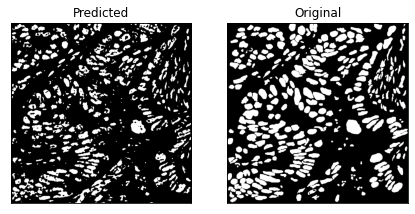

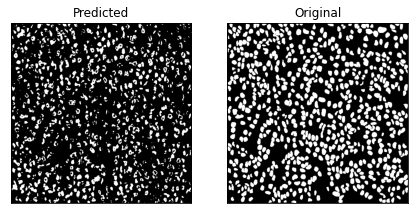

In [65]:
for i in range (y_2layer.shape[0]):
  plt.figure(figsize=(11,6))
  plt.subplot(131), plt.imshow(res_2layer[i],cmap='gray'),plt.title('Predicted')
  plt.xticks([]), plt.yticks([])
  plt.subplot(132), plt.imshow(yTrue_2layer[i],cmap='gray'),plt.title('Original')
  plt.xticks([]), plt.yticks([])
  plt.show()

Testing data

In [66]:
# Weights
model_2layer.save_weights("UNetW.h5")

# Dataset for prediction
x_2layer, y_2layer = test_gen.__getitem__(1)
result_2layer = model_2layer.predict(x_2layer)
print(x_2layer.shape, y_2layer.shape, result_2layer.shape)
result_2layer = result_2layer > 0.5

yTrue_2layer = [0]*y_2layer.shape[0]
res_2layer = [0]*y_2layer.shape[0]

for i in range (y_2layer.shape[0]):
  res_2layer[i] = result_2layer[i][:, :, 0]*255
  yTrue_2layer[i] = y_2layer[i][:, :, 0]*255
  print(yTrue_2layer[0].shape, res_2layer[0].shape)

1/1 [==============================] - 0s 31ms/step
(4, 512, 512, 3) (4, 512, 512, 3) (4, 512, 512, 1)
(512, 512) (512, 512)
(512, 512) (512, 512)
(512, 512) (512, 512)
(512, 512) (512, 512)


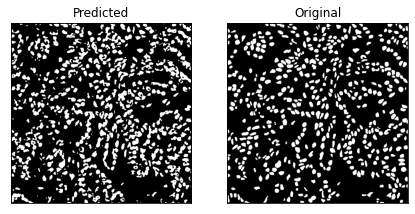

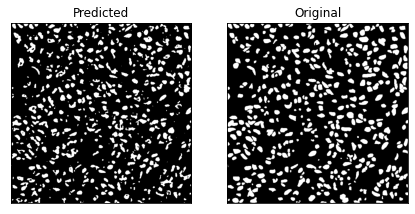

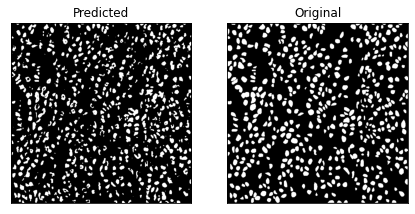

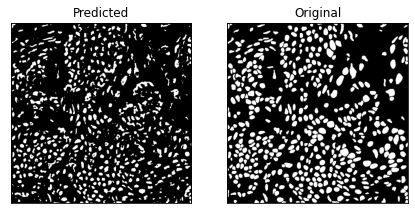

In [67]:
for i in range (y_2layer.shape[0]):
  plt.figure(figsize=(11,6))
  plt.subplot(131), plt.imshow(res_2layer[i],cmap='gray'),plt.title('Predicted')
  plt.xticks([]), plt.yticks([])
  plt.subplot(132), plt.imshow(yTrue_2layer[i],cmap='gray'),plt.title('Original')
  plt.xticks([]), plt.yticks([])
  plt.show()